In [ ]:
"""
Week 3 Exercise
Nonlinear Functions, R², and Transformations

In this assignment, we:
- Explore nonlinear relationships using US population data
- Compare two models using R²
- Apply a log transformation to customer spending data
"""

'\nWeek 3 Exercise\nNonlinear Functions, R², and Transformations\n\nIn this assignment, we:\n- Explore nonlinear relationships using US population data\n- Compare two models using R²\n- Apply a log transformation to customer spending data\n'

### **Assignment Setup**
* Import Libraries
* Load Data
* Verify/Preview data

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [ ]:
# Load the data file(s)
us_df = pd.read_csv('https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/us_pop_data_3.csv')
customer_df = pd.read_csv('https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/customer_spending_3.csv')

In [ ]:
# Verify Load of df for us data
us_df.head()

,year,us_pop
0,1790,3929326
1,1800,5308483
2,1810,7239881
3,1820,9638453
4,1830,12866020


In [ ]:
# Verify Load of df for us data
customer_df.head()

,ann_spending
0,34112
1,33266
2,36610
3,27381
4,46100


---
# **US Population Growth Instructions**
For this problem, you will be using the data set `us_pop_data.csv`. This data is from taken from the US Census has the US population every ten years from 1790 to 2010.

---

### **Problem A**
(a) Import the data and create two new columns. Create one column that is the number of years since 1790. Create another column that is the population in millions.

In [ ]:
# Convert year into "years since 1790" to make it easier to model
us_df["years_since_1790"] = us_df["year"] - 1790

# Convert population to millions to make numbers easier to read
us_df["pop_millions"] = us_df["us_pop"] / 1_000_000

print(us_df.head())

   year    us_pop  years_since_1790  pop_millions
0  1790   3929326                 0      3.929326
1  1800   5308483                10      5.308483
2  1810   7239881                20      7.239881
3  1820   9638453                30      9.638453
4  1830  12866020                40     12.866020


### **Problem B**
(b) Plot the US population (in millions) versus the years since 1790.

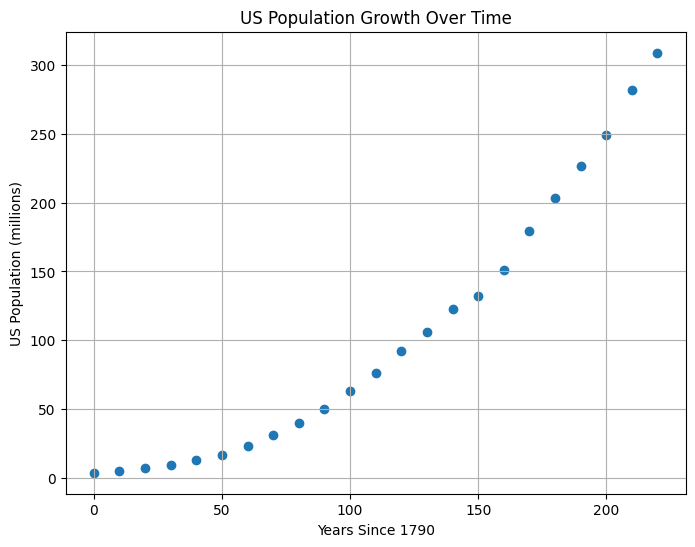

In [ ]:
"""
This plot helps us visually see the relationship.
We expect a curved (nonlinear) pattern rather than a straight line.
"""

plt.figure(figsize=(8, 6))
plt.scatter(us_df["years_since_1790"], us_df["pop_millions"])
plt.xlabel("Years Since 1790")
plt.ylabel("US Population (millions)")
plt.title("US Population Growth Over Time")
plt.grid(True)
plt.show()

### **Problem C**
(c) Create a linear regression model to predict the US population (in millions) t years from 1790. Find and report the R2-value of this model.




In [ ]:
"""
Here we build a simple linear model.
This assumes population grows in a straight line over time.
"""

x_linear = us_df[["years_since_1790"]]
y_pop = us_df["pop_millions"]

linear_model = LinearRegression()
linear_model.fit(x_linear, y_pop)

# Generate predictions from the model
linear_predictions = linear_model.predict(x_linear)

# R² tells us how well the model fits the data
r2_linear = linear_model.score(x_linear, y_pop)

print("Linear model slope:", linear_model.coef_[0])
print("Linear model intercept:", linear_model.intercept_)
print("Linear model R^2:", r2_linear)

Linear model slope: 1.359624838043478
Linear model intercept: -45.567876097826044
Linear model R^2: 0.9192437447080442


### **Problem D**
(d) Create another new column in your data by squaring the number of years since 1790.

In [ ]:
"""
We add a squared term to capture curvature in the data.
This allows us to model nonlinear growth.
"""

us_df["years_since_1790_sq"] = us_df["years_since_1790"] ** 2

print(us_df.head())

   year    us_pop  years_since_1790  pop_millions  years_since_1790_sq
0  1790   3929326                 0      3.929326                    0
1  1800   5308483                10      5.308483                  100
2  1810   7239881                20      7.239881                  400
3  1820   9638453                30      9.638453                  900
4  1830  12866020                40     12.866020                 1600


### **Problem E**
(e) Run another linear regression, where your input feature is the square of the number of years since 1790. Find and report the R2-value of this model.



In [ ]:
"""
This model uses the squared feature instead of the original one.
This helps capture the curved growth pattern.
"""

x_squared = us_df[["years_since_1790_sq"]]

squared_model = LinearRegression()
squared_model.fit(x_squared, y_pop)

squared_predictions = squared_model.predict(x_squared)
r2_squared = squared_model.score(x_squared, y_pop)

print("Squared model slope:", squared_model.coef_[0])
print("Squared model intercept:", squared_model.intercept_)
print("Squared model R^2:", r2_squared)

Squared model slope: 0.006220027007947026
Squared model intercept: 1.3604104558305892
Squared model R^2: 0.9984915694986646


### **Problem F**
(f) Plot the models you built on top of the data. Which one fits the data better? Is this apparent in your R2-values. Explain.

**Answer**: The model using the square of years since 1790 fits the data better. A regular linear model assumes the relationship is a straight line, meaning population would increase at a constant rate over time. However, the population data shows a curved pattern where growth starts slower and then increases more rapidly, so a straight line does not capture that behavior well. By squaring the input, the model is able to represent this curvature, since larger values grow much faster when squared. This allows the model to better match the accelerating growth pattern seen in the data.

Squaring the input creates a curved relationship, but it only works well if the data actually follows that type of curve. A squared input produces a specific parabolic shape, so while it can improve the model compared to a straight line, it may not always be the best choice. Different datasets may require different types of functions, such as exponential or logarithmic models, depending on the pattern in the data.

This is also reflected in the R² values, where the squared model has a much higher value (0.9985) compared to the linear model (0.9192), indicating a much better fit.

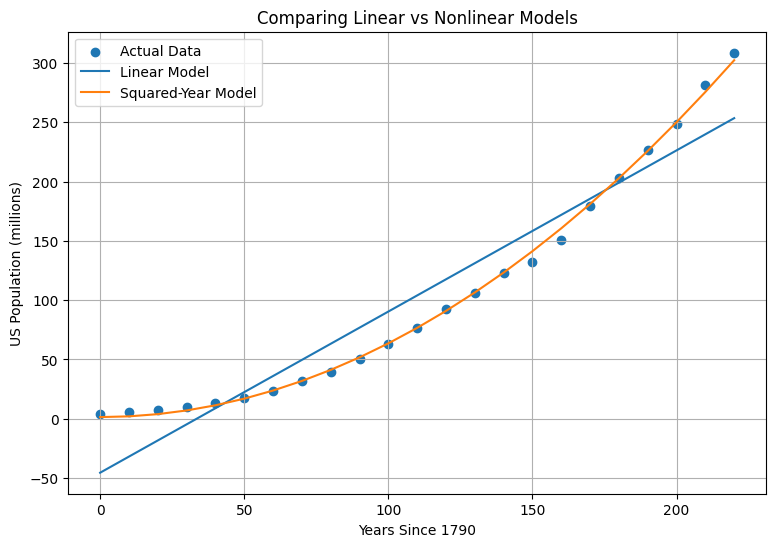

In [ ]:
"""
This helps visually compare how well each model fits the data.
"""

# Sort values so lines plot cleanly
sorted_idx = us_df["years_since_1790"].argsort()

plt.figure(figsize=(9, 6))

# Actual data
plt.scatter(
    us_df["years_since_1790"],
    us_df["pop_millions"],
    label="Actual Data"
)

# Linear model line
plt.plot(
    us_df["years_since_1790"].iloc[sorted_idx],
    linear_predictions[sorted_idx],
    label="Linear Model"
)

# Nonlinear (squared) model line
plt.plot(
    us_df["years_since_1790"].iloc[sorted_idx],
    squared_predictions[sorted_idx],
    label="Squared-Year Model"
)

plt.xlabel("Years Since 1790")
plt.ylabel("US Population (millions)")
plt.title("Comparing Linear vs Nonlinear Models")
plt.legend()
plt.grid(True)
plt.show()

---
# **Customer Spending Data Instructions**

For this problem, you will be using the data set `customer_spending.csv`. This data set is modified version of the data from https://archive.ics.uci.edu/ml/datasets/Wholesale+customers.

---

### **Problem A**
(a) Make a histogram of the customer spending amounts.


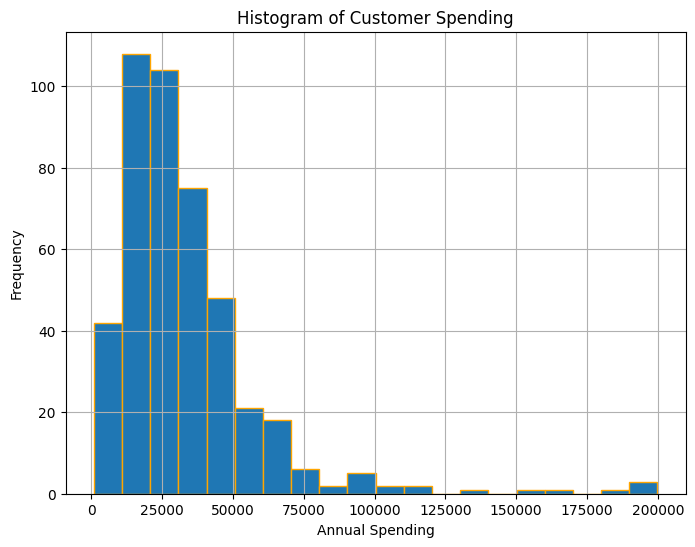

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(customer_df["ann_spending"], bins=20, edgecolor="orange")
plt.xlabel("Annual Spending")
plt.ylabel("Frequency")
plt.title("Histogram of Customer Spending")
plt.grid(True)

### **Problem B**
(b) Make a new data set that is a log transformation of the customer spending amounts.

In [ ]:
"""
Log transformation reduces the effect of very large values.
This helps make the data more balanced.
"""

customer_log_df = customer_df.copy()
customer_log_df["log_ann_spending"] = np.log(customer_log_df["ann_spending"])

print(customer_log_df.head())

   ann_spending  log_ann_spending
0         34112         10.437405
1         33266         10.412291
2         36610         10.508077
3         27381         10.217605
4         46100         10.738568


### **Problem C**
(c) Make a histogram of the log transformed dataset.

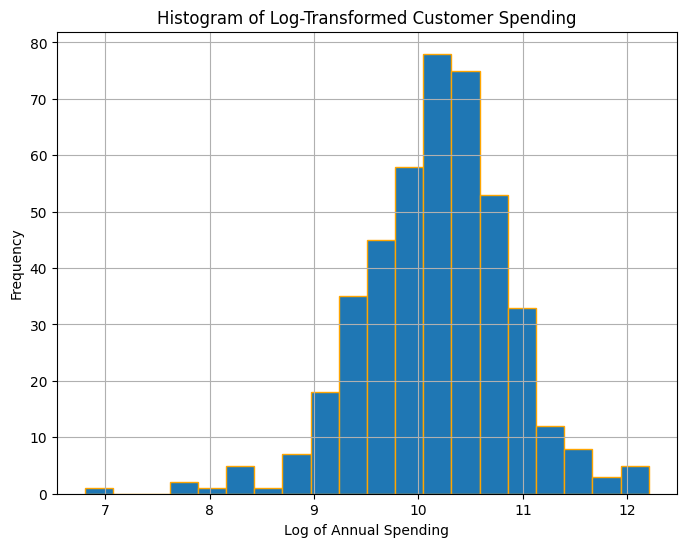

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(customer_log_df["log_ann_spending"], bins=20, edgecolor="orange")
plt.xlabel("Log of Annual Spending")
plt.ylabel("Frequency")
plt.title("Histogram of Log-Transformed Customer Spending")
plt.grid(True)

### **Problem D**
(d) Compare the two histograms. Discuss why it might be useful to apply a log transformation to this data for modeling purposes.

**Answer**: The original customer spending histogram is right-skewed, meaning most customers spend lower to moderate amounts, with a smaller number of customers spending significantly more. After applying the log transformation, the distribution becomes more balanced and less skewed. This happens because the log transformation compresses large values while keeping smaller values more spread out, making the overall range of the data more manageable.

For example, if one customer spends 1,000 and another spends 100,000, the difference is very large on a linear scale. However, using a log base 10 transformation, log10(1,000) = 3 and log10(100,000) = 5. Now the difference is only 2 instead of 99,000. This shows how log transformation compresses large values and brings them closer together, making it easier to compare data across a wide range.

This is useful for modeling because extreme values (very high spenders) can have a large influence on the model and distort the results. By applying a log transformation, those large values are reduced in scale, allowing the model to better capture patterns across the majority of the data. It also helps when the data follows exponential-like behavior, which is common in things like spending or financial data.